## Data Preprocessing and Augmentation

Before training the CNN model the CIFAR-10 dataset was preprocessed to make it more suitable for image classification. The first step involved scaling the pixel values from the original range of 0 to 255 to a normalized range between 0 and 1. This was done to improve training stability and allow the neural network to learn more effectively.

The class labels were then converted into one-hot encoded vectors. Since CIFAR-10 is a multi-class classification problem with ten possible categories one-hot encoding allows each class label to be represented in a format suitable for the output layer of the CNN.

To improve the model’s generalization ability and reduce overfitting data augmentation was applied to the training images. This involved generating slightly modified versions of the original images during training. The augmentation methods used were horizontal flipping, small rotations and small translations. These transformations were selected because they preserve the overall meaning of the images while helping the model become more robust to variations in object position and orientation.

This preprocessing and augmentation pipeline was chosen based on standard deep learning practice for image classification tasks and is appropriate for the CIFAR-10 dataset.


In [1]:
# Import required libraries
# TensorFlow is used to build and train the neural network
import tensorflow as tf

# Keras built-in dataset CIFAR-10
from tensorflow.keras.datasets import cifar10

# Used to convert class labels into one-hot encoded vectors
from tensorflow.keras.utils import to_categorical


# Load the CIFAR-10 dataset
# The dataset contains 60,000 images size 32x32 pixels

(X_train, y_train), (X_test, y_test) = cifar10.load_data()


# Normalize image pixel values
# Images originally contain pixel values from 0 to 255
# Neural networks perform better when input values are scaled
# Dividing by 255 converts pixel values into the range 0–1

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


# Convert labels to one-hot encoding
# CIFAR-10 has 10 object classes
# One-hot encoding converts class numbers into binary vectors
# Example: class "3" becomes [0,0,0,1,0,0,0,0,0,0]

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)


# Display dataset shapes to verify everything loaded correctly

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test.shape)


c:\Users\killi\anaconda3\envs\ml\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 10)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 10)


In [2]:
# Create a data augmentation pipeline
# Data augmentation increases the diversity of the training data by applying small random transformations to images.
# This helps reduce overfitting and improves model generalization.

data_augmentation = tf.keras.Sequential([

    # Randomly flip images horizontally
    # This helps the model recognise objects from mirrored viewpoints
    tf.keras.layers.RandomFlip("horizontal"),

    # Randomly rotate images slightly
    # This helps the model detect objects that are slightly tilted
    tf.keras.layers.RandomRotation(0.1),

    # Randomly shift images horizontally and vertically
    # This helps the model handle small positional changes
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1)

])

print("Data augmentation pipeline created successfully.")


Data augmentation pipeline created successfully.


## Visualizing Sample Images

Before training the CNN model visualise some examples from the CIFAR-10 dataset. This helps confirm that the images were loaded correctly and shows the types of objects the model will need to classify.

The CIFAR-10 dataset contains 10 different classes including airplanes, automobiles, birds, cats, deer, dogs, frogs, horses, ships and trucks. Displaying a small sample of images helps inspect the dataset and verify that the preprocessing steps have been applied correctly.


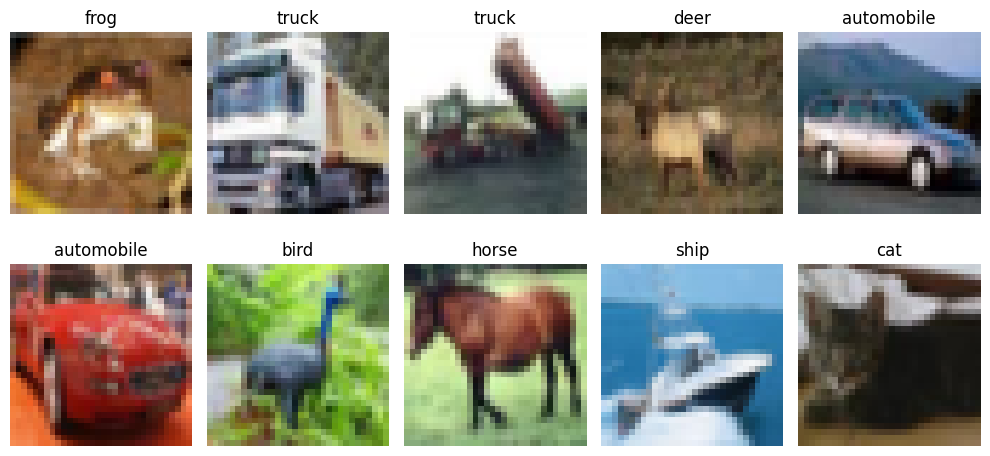

In [3]:
# Import libraries for visualization
import matplotlib.pyplot as plt
import numpy as np

# Define the class names for CIFAR-10
# These correspond to the numeric labels in the dataset
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Display the first 10 images from the training dataset
# This allows inspection of the dataset and confirmation that the images have loaded correctly

plt.figure(figsize=(10,5))

for i in range(10):
    
    # Create subplot grid
    plt.subplot(2,5,i+1)
    
    # Display image
    plt.imshow(X_train[i])
    
    # Show the class label for the image
    plt.title(class_names[np.argmax(y_train[i])])
    
    plt.axis("off")

# Adjust layout
plt.tight_layout()

# Display images
plt.show()
